### **Import Liberaries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
custom_palette = sns.color_palette("Blues_d", 8)

C:\Users\user6\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\user6\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### **Loading Dataset**

In [2]:
df = pd.read_csv("airline.csv")
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


### **Explore Data Analysis (EDA)**

In [3]:
df.shape

(25976, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [5]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25893.000000
mean,12987.500000,65005.657992,39.620958,1193.788459,2.724746,3.046812,2.756775,2.977094,3.215353,3.261665,3.449222,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.740857
std,7498.769632,37611.526647,15.135685,998.683999,1.335384,1.533371,1.412951,1.282133,1.331506,1.355536,1.320090,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.517539
min,0.000000,17.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,6493.750000,32170.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000
50%,12987.500000,65319.500000,40.000000,849.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,19481.250000,97584.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000
max,25975.000000,129877.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1128.00000,1115.000000


In [6]:
cat_columns = df.select_dtypes(include='object').columns
for col in cat_columns:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("-" * 30)

Column: Gender
Gender
Female    13172
Male      12804
Name: count, dtype: int64
------------------------------
Column: Customer Type
Customer Type
Loyal Customer       21177
disloyal Customer     4799
Name: count, dtype: int64
------------------------------
Column: Type of Travel
Type of Travel
Business travel    18038
Personal Travel     7938
Name: count, dtype: int64
------------------------------
Column: Class
Class
Business    12495
Eco         11564
Eco Plus     1917
Name: count, dtype: int64
------------------------------
Column: satisfaction
satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64
------------------------------


C:\Users\user6\AppData\Local\Temp\ipykernel_23164\564387828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include='object').columns


C:\Users\user6\AppData\Local\Temp\ipykernel_23164\2629248387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='satisfaction', palette=['#ADD8E6', '#1D4ED8'])


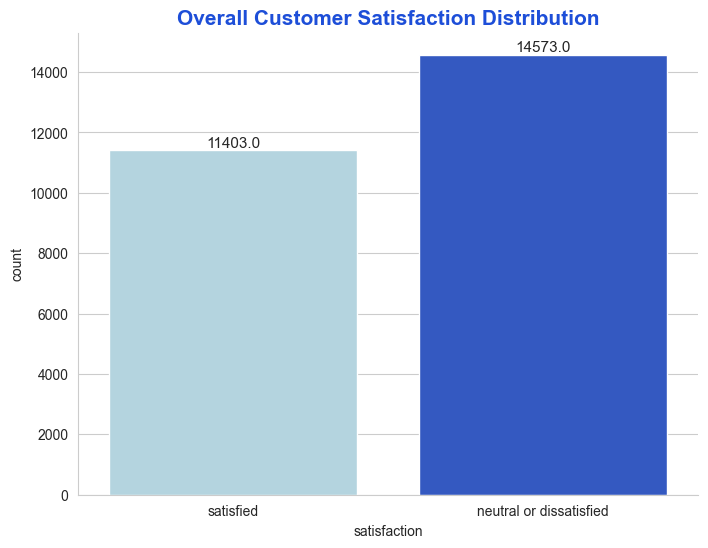

In [7]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='satisfaction', palette=['#ADD8E6', '#1D4ED8'])
plt.title('Overall Customer Satisfaction Distribution', fontsize=15, fontweight='bold', color='#1D4ED8')
sns.despine()
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='bottom', fontsize=11)
plt.show()

### **Data Preprocessing**

In [8]:
print(f"Old Shape: {df.shape}")
df = df.drop(['Unnamed: 0', 'id'], axis=1)
print(f"New shape: {df.shape}")

Old Shape: (25976, 25)
New shape: (25976, 23)


#### **Missing Values**

In [9]:
df.isna().sum()

Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

In [10]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [11]:
df.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

#### **Duplicated Values**

In [12]:
df.duplicated().sum()

0

#### **Checking for Outliers**

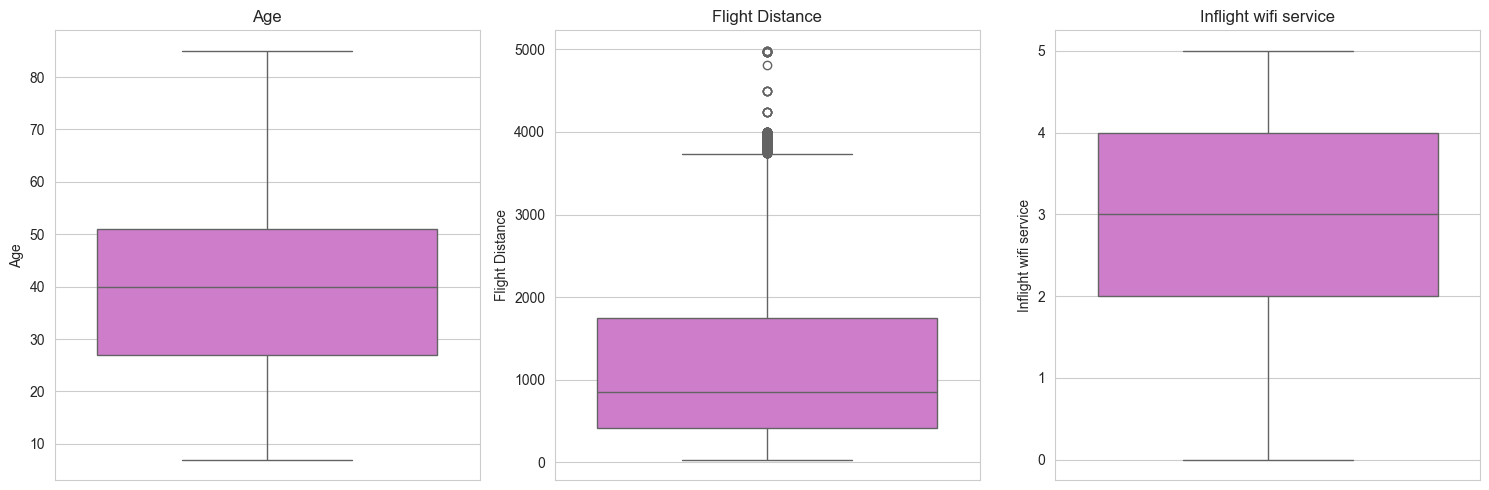

In [13]:
features1 = ['Age', 'Flight Distance', 'Inflight wifi service']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features1):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='orchid')
    plt.title(col)
plt.tight_layout()
plt.show()

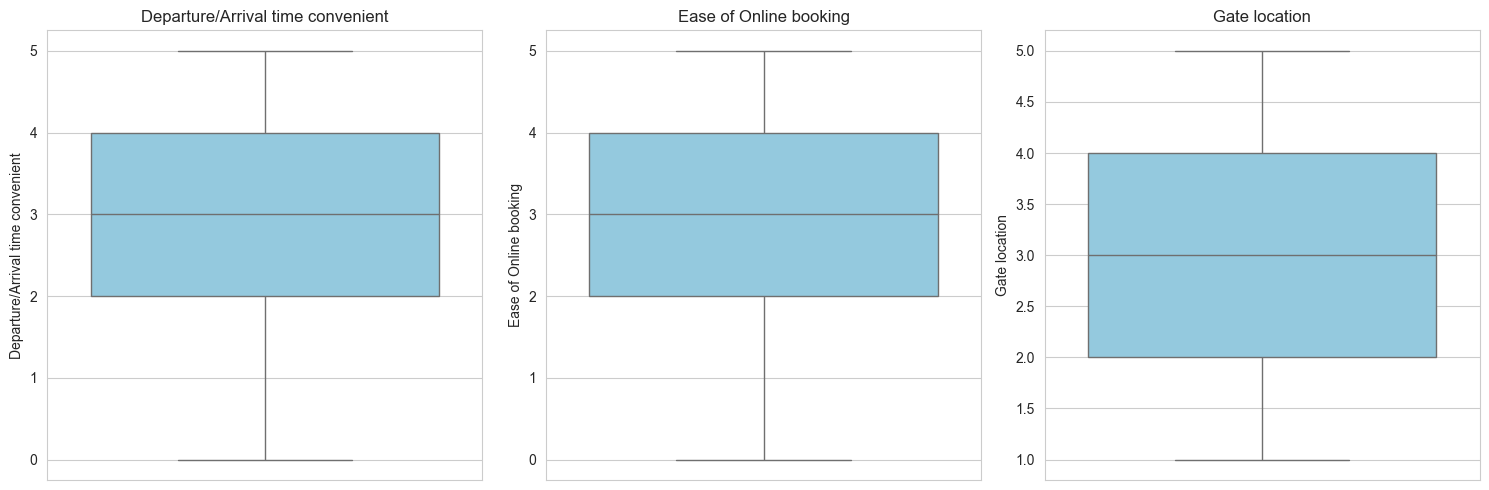

In [14]:
features2 = ['Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features2):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

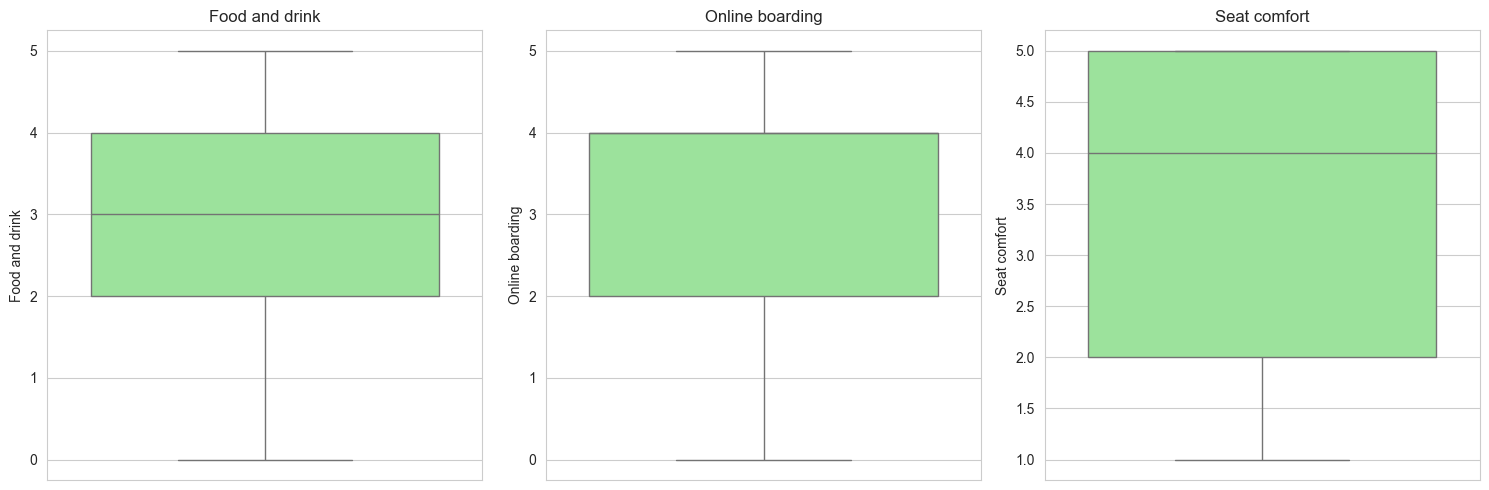

In [15]:
features3 = ['Food and drink', 'Online boarding', 'Seat comfort']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features3):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

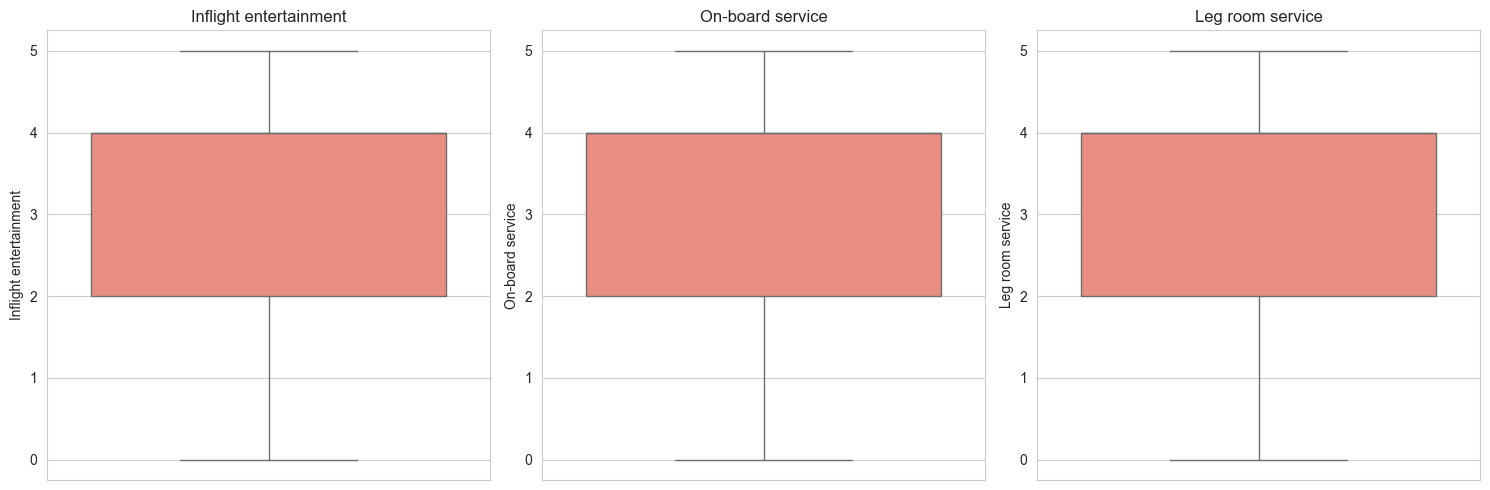

In [16]:
features4 = ['Inflight entertainment', 'On-board service', 'Leg room service']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features4):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(col)
plt.tight_layout()
plt.show()

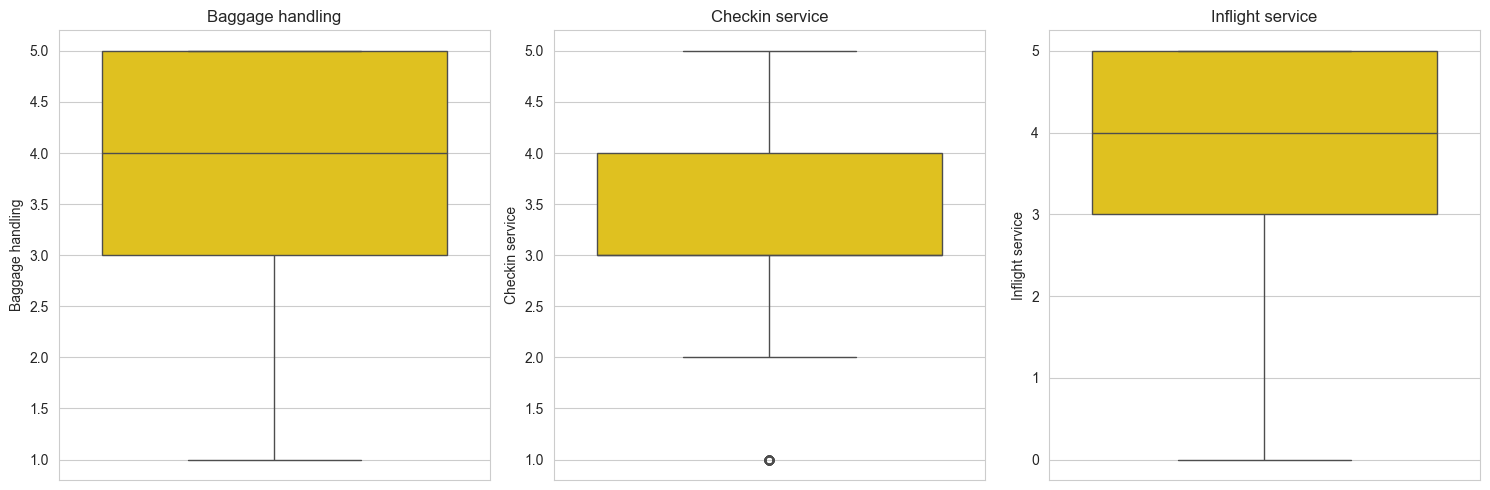

In [17]:
features5 = ['Baggage handling', 'Checkin service', 'Inflight service']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features5):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='gold')
    plt.title(col)
plt.tight_layout()
plt.show()

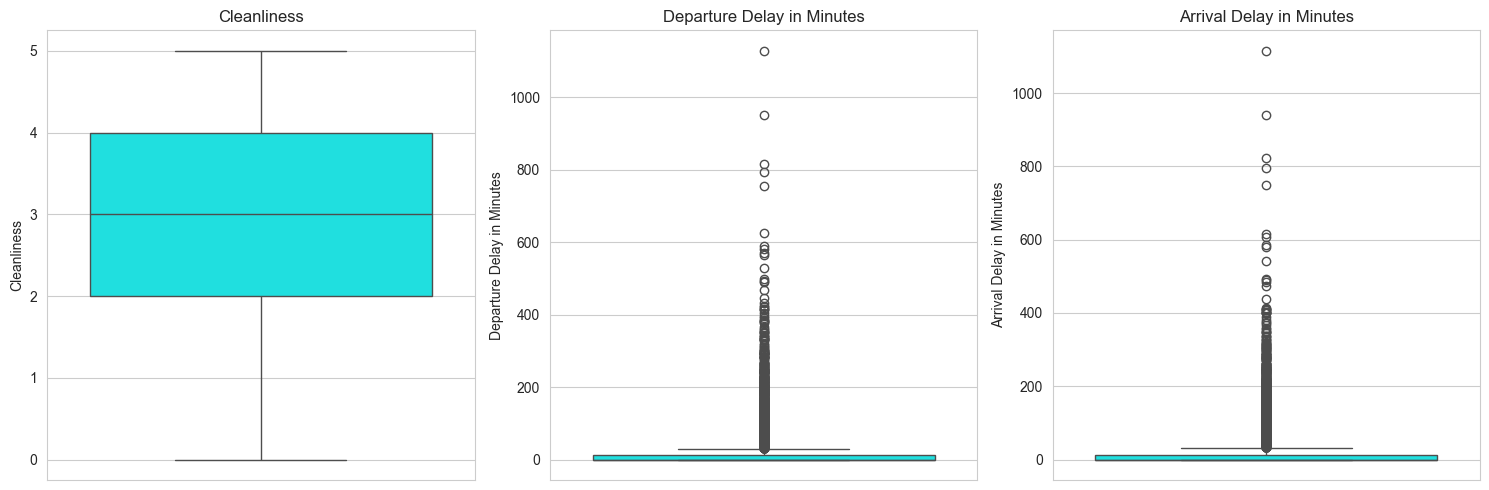

In [18]:
features6 = ['Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features6):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='cyan') 
    plt.title(col)

plt.tight_layout()
plt.show()

#### **Visualization**

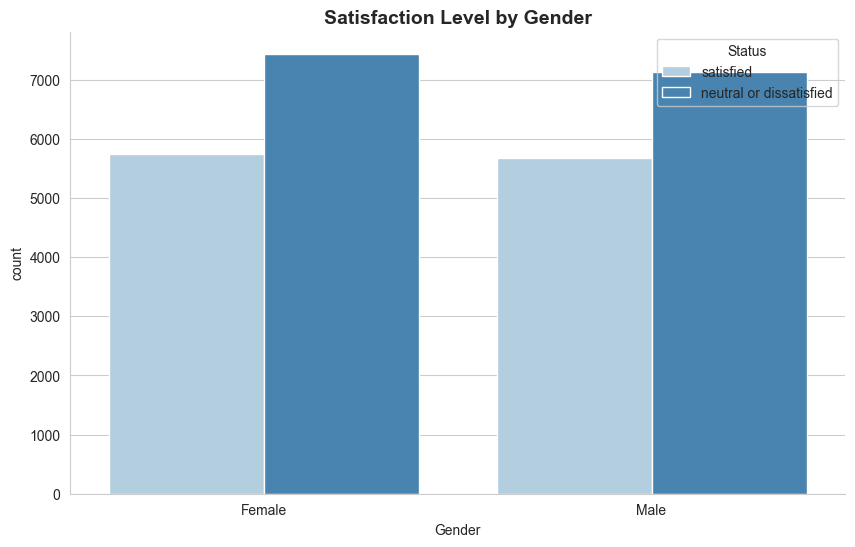

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='satisfaction', palette='Blues')
plt.title('Satisfaction Level by Gender', fontsize=14, fontweight='bold')
plt.legend(title='Status', loc='upper right')
sns.despine()
plt.show()

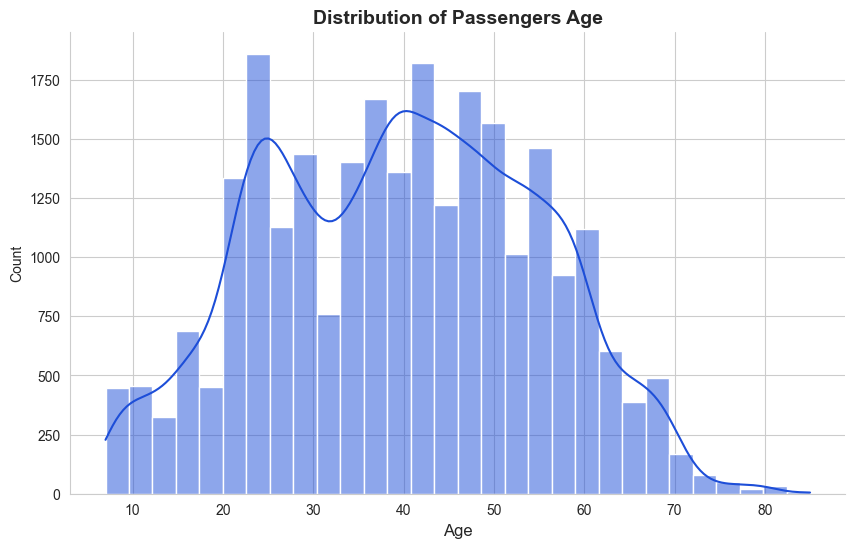

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='#1D4ED8', bins=30)
plt.title('Distribution of Passengers Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
sns.despine()
plt.show()

C:\Users\user6\AppData\Local\Temp\ipykernel_23164\1079523524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='satisfaction', y='Flight Distance', palette='Blues', width=0.5)


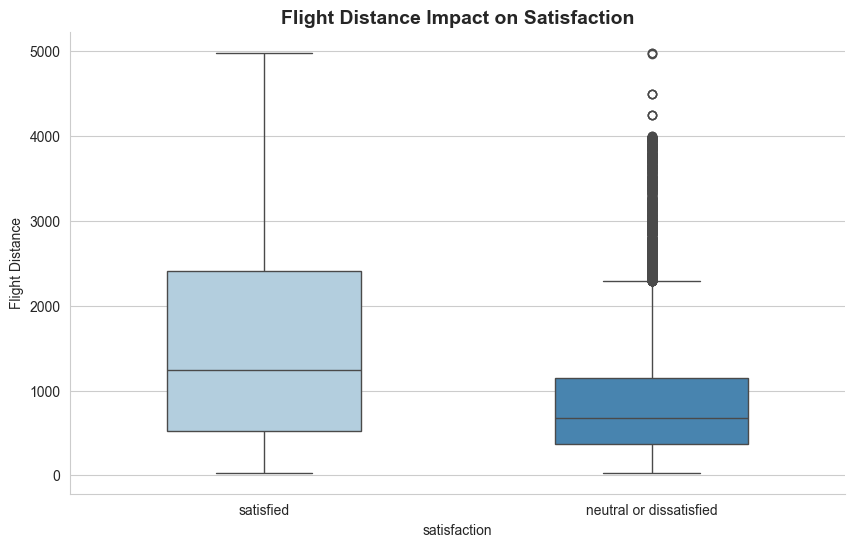

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='satisfaction', y='Flight Distance', palette='Blues', width=0.5)
plt.title('Flight Distance Impact on Satisfaction', fontsize=14, fontweight='bold')
sns.despine()
plt.show()

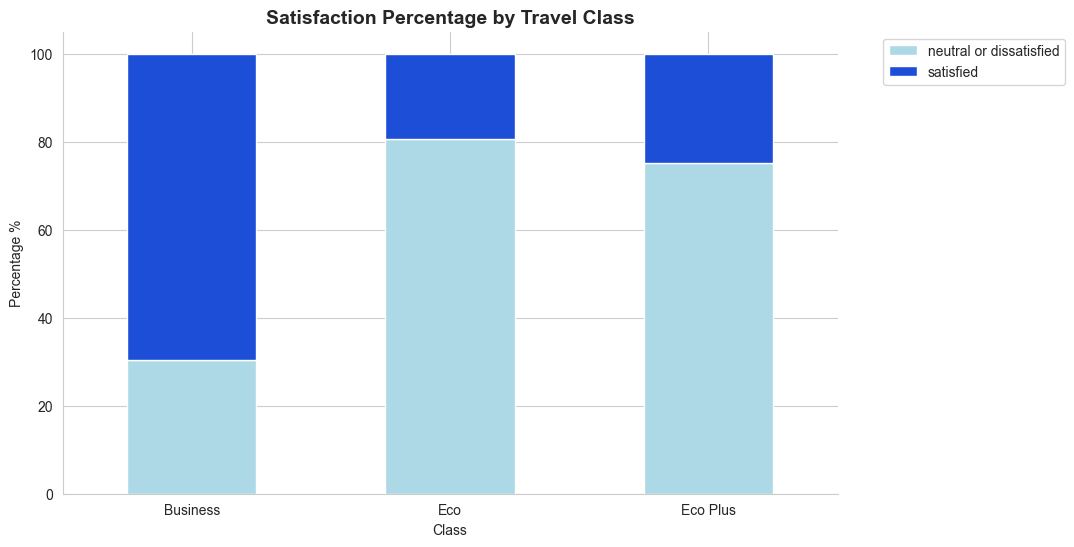

In [22]:
class_sat = pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100
class_sat.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ADD8E6', '#1D4ED8'])
plt.title('Satisfaction Percentage by Travel Class', fontsize=14, fontweight='bold')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


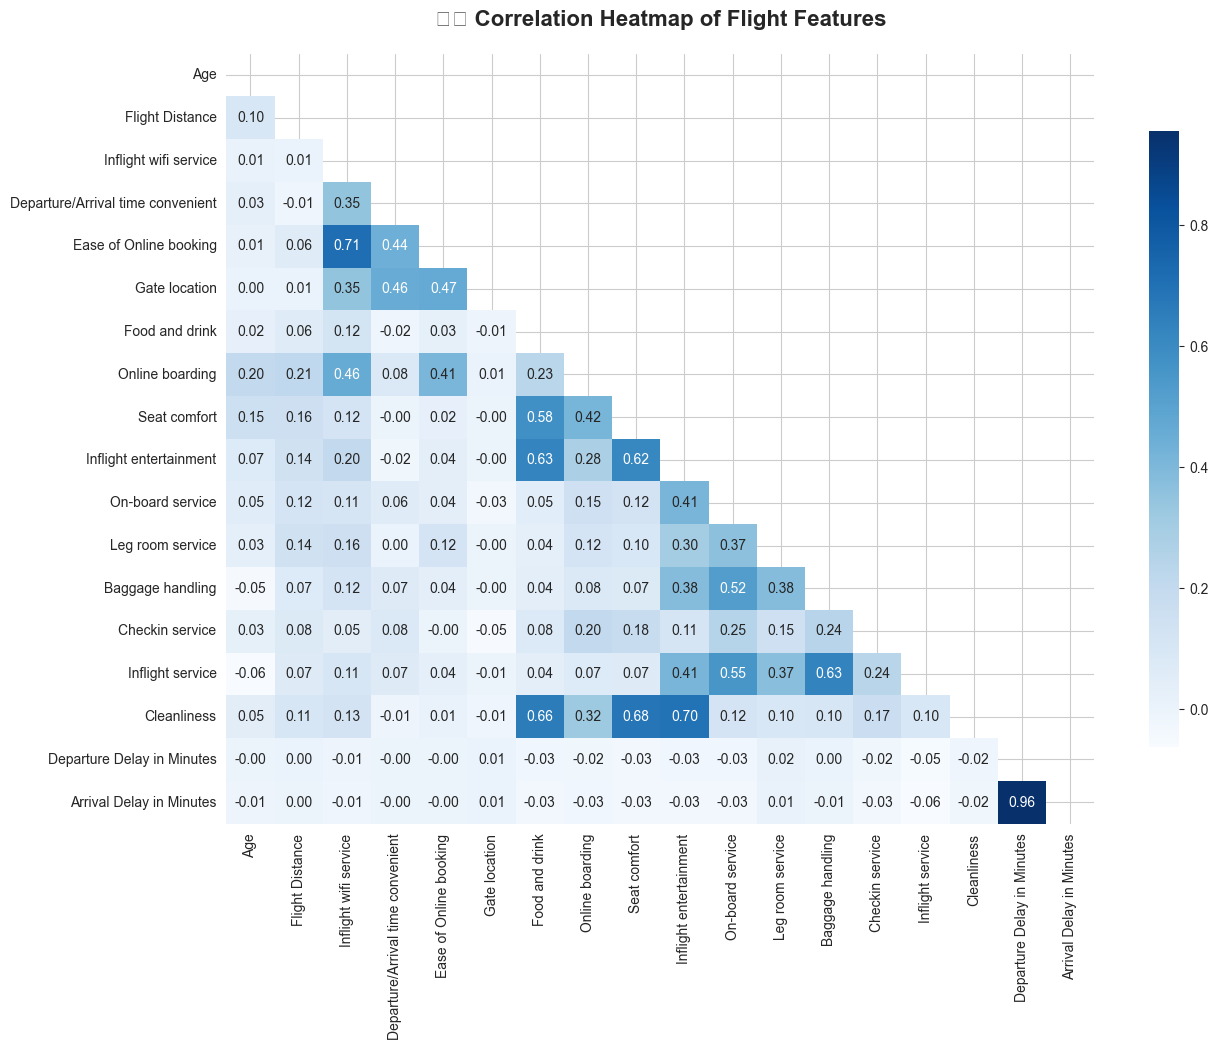

In [23]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Blues', cbar_kws={"shrink": .8})
plt.title('🌡️ Correlation Heatmap of Flight Features', fontsize=16, fontweight='bold', pad=20)
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129523 (\N{LUGGAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


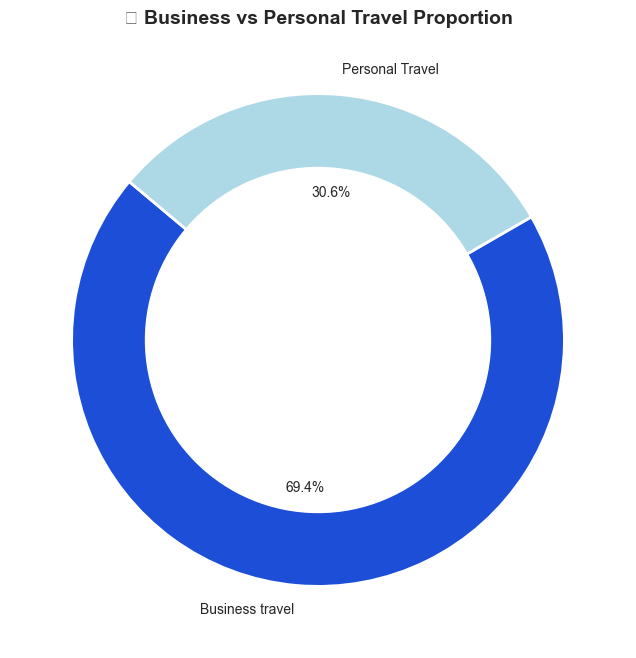

In [24]:
plt.figure(figsize=(8, 8))
space = df['Type of Travel'].value_counts()
plt.pie(space, labels=space.index, autopct='%1.1f%%', startangle=140, 
        colors=['#1D4ED8', '#ADD8E6'], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('🧳 Business vs Personal Travel Proportion', fontsize=14, fontweight='bold')
plt.show()

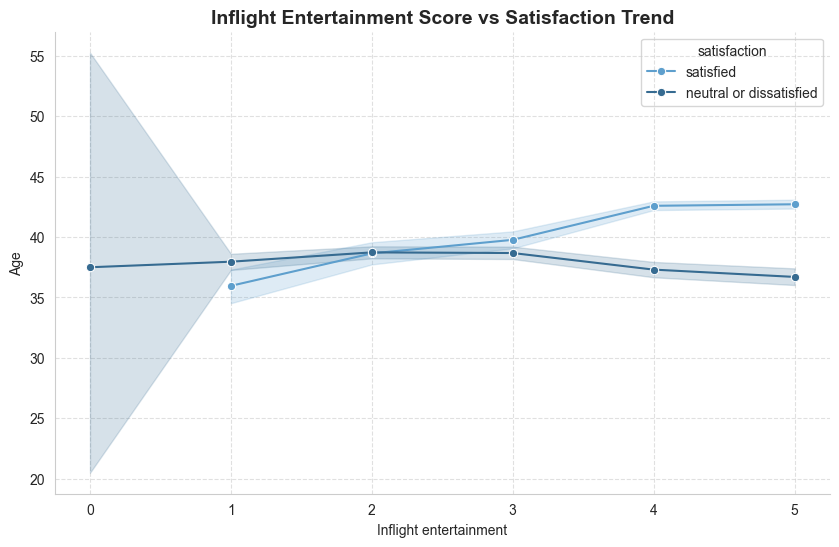

In [25]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Inflight entertainment', y='Age', hue='satisfaction', marker='o', palette='Blues_d')
plt.title('Inflight Entertainment Score vs Satisfaction Trend', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.show()

#### **Encoding**

In [26]:
df = pd.get_dummies(df, columns=["Gender","Customer Type", "Type of Travel", "Class"]) # One-Hot encoding

In [27]:
le = LabelEncoder()
df['satisfaction'] = le.fit_transform(df['satisfaction'])

In [28]:
df.shape

(25976, 28)

#### **Identify Target**

In [29]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

#### **Splitting Data**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
    )

### **Random Forest Model**

In [31]:
rf_model = RandomForestClassifier( n_estimators=100, max_depth=7, random_state=42 )

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [32]:
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)
accuracy_train = accuracy_score(y_train, y_pred_train_rf)
accuracy_test = accuracy_score(y_test, y_pred_test_rf)

print("=" * 60)
print("MODEL ACCURACY")
print("=" * 60)
print(f"Train Accuracy: {accuracy_train * 100:.2f}%")
print(f"Test Accuracy:  {accuracy_test * 100:.2f}%")
print("=" * 60)

MODEL ACCURACY
Train Accuracy: 93.88%
Test Accuracy:  92.92%


In [33]:
print("=" * 60)
print("📊 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_test_rf))

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2945
           1       0.92      0.92      0.92      2251

    accuracy                           0.93      5196
   macro avg       0.93      0.93      0.93      5196
weighted avg       0.93      0.93      0.93      5196



### **XGBoost Model**

In [34]:
xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)
accuracy_train = accuracy_score(y_train, y_pred_train_xgb)
accuracy_test = accuracy_score(y_test, y_pred_test_xgb)

print("=" * 60)
print("MODEL ACCURACY")
print("=" * 60)
print(f"Train Accuracy: {accuracy_train * 100:.2f}%")
print(f"Test Accuracy:  {accuracy_test * 100:.2f}%")
print("=" * 60)

MODEL ACCURACY
Train Accuracy: 96.41%
Test Accuracy:  95.36%


In [36]:
print("=" * 60)
print("📊 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_test_xgb))

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2945
           1       0.96      0.94      0.95      2251

    accuracy                           0.95      5196
   macro avg       0.95      0.95      0.95      5196
weighted avg       0.95      0.95      0.95      5196



### **Model Comparison**

In [37]:
comparison_data = []

models_list = {
    "Random Forest": y_pred_test_rf,
    "XGBoost": y_pred_test_xgb
}

for name, preds in models_list.items():
    acc = accuracy_score(y_test, preds) * 100
    rec = recall_score(y_test, preds, pos_label=1) * 100
    f1 = f1_score(y_test, preds, pos_label=1) * 100
    pre = precision_score(y_test, preds) * 100
    
    comparison_data.append({
        "Model": name, 
        "Accuracy": acc, 
        "F1-Score": f1,
        "Precision": pre,
        "Recall": rec
    })

comparison_df = pd.DataFrame(comparison_data)

styled_comparison = comparison_df.style.set_caption("🚀 Final Models Performance Comparison")\
    .format({col: "{:.2f}%" for col in ["Accuracy", "F1-Score", "Precision", "Recall"]})\
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#1D4ED8'), ('font-size', '20px'), 
                                         ('font-weight', 'bold'), ('text-align', 'center'), 
                                         ('padding-bottom', '15px')]},
        {'selector': 'th', 'props': [('background-color', '#ADD8E6'), ('color', '#000000'), 
                                     ('font-weight', 'bold'), ('border', '1px solid #CFE2F3'),
                                     ('text-align', 'center'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('background-color', 'white'), ('color', '#000000'),
                                     ('border', '1px solid #E0E0E0'), ('text-align', 'center'), 
                                     ('padding', '10px')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '80%'), 
                                         ('margin', 'auto')]}
    ])\
    .hide(axis="index")

styled_comparison

Model,Accuracy,F1-Score,Precision,Recall
Random Forest,92.92%,91.81%,91.98%,91.65%
XGBoost,95.36%,94.60%,95.52%,93.69%


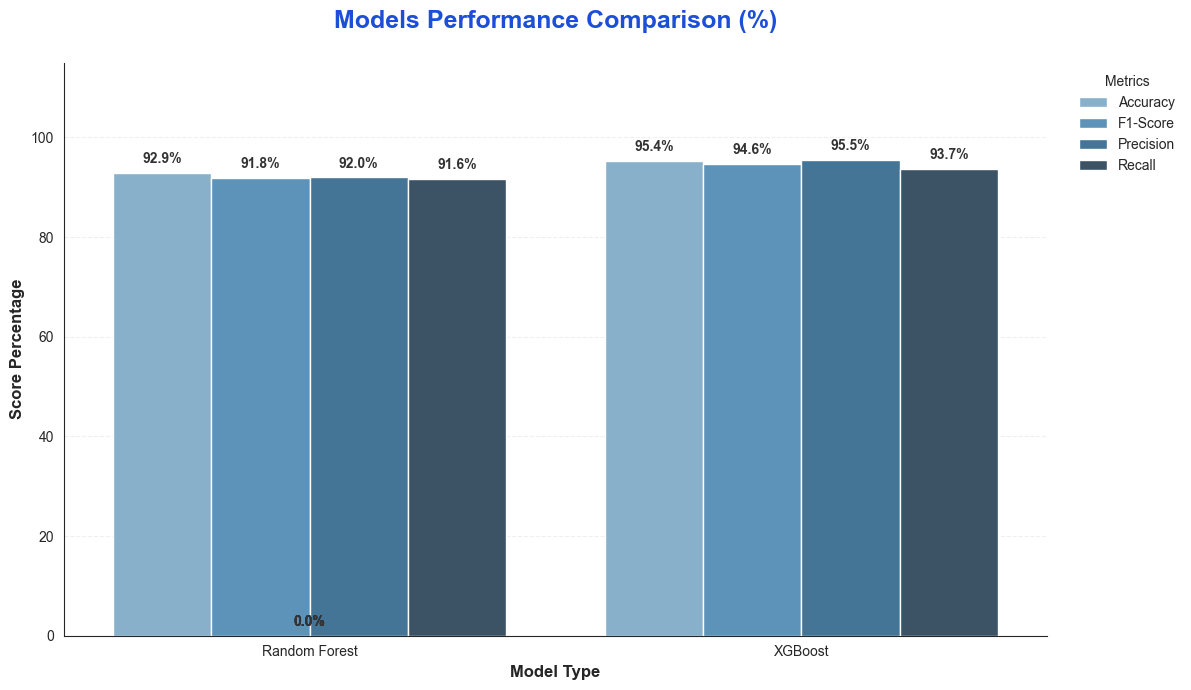

In [38]:
df_plot = comparison_df.copy()
for col in ["Accuracy", "F1-Score", "Precision", "Recall"]:
    if df_plot[col].dtype == 'object':
        df_plot[col] = df_plot[col].str.replace('%', '').astype(float)

df_melted = df_plot.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.set_style("white")
plt.figure(figsize=(12, 7))

ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette="Blues_d")

plt.title("Models Performance Comparison (%)", fontsize=18, fontweight='bold', pad=25, color='#1D4ED8')
plt.ylabel("Score Percentage", fontsize=12, fontweight='bold')
plt.xlabel("Model Type", fontsize=12, fontweight='bold')
plt.ylim(0, 115)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#333333',
                xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.legend(title="Metrics", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### **Save Models and Requirements**

In [39]:
# Exporting XGBoost model and requirements
joblib.dump(xgb_model, "xgb_model.pkl") 
joblib.dump(le, "label_encoder.pkl")
joblib.dump(list(X_train.columns), "model_columns.pkl")

print("="*50)
print("🚀 Deployment files exported successfully!")
print("📦 Saved: xgb_model.pkl")
print("🏷️ Saved: label_encoder.pkl")
print("📋 Saved: model_columns.pkl")
print("="*50)

🚀 Deployment files exported successfully!
📦 Saved: xgb_model.pkl
🏷️ Saved: label_encoder.pkl
📋 Saved: model_columns.pkl
